# Customer Analytics and Churn Prediction

## Overview

This notebook presents the exploratory data analysis, customer-level feature engineering, and machine learning analysis performed on the synthetic customer order dataset.

The analysis covers:

- Exploratory Data Analysis (EDA)
- Revenue and category analysis
- Customer behavior analysis
- Customer-level feature engineering
- Inactivity classification
- Logistic Regression and Random Forest models
- Model evaluation
- Feature importance analysis

> **Note:** The customer and order data used in this module is synthetically generated from the scraped product catalog. It does not represent real Zepto customer transaction data.

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load the synthetic customer order dataset
df = pd.read_csv("../data/customer_orders.csv")

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
display(df.head())

Dataset shape: (1500, 12)

First 5 rows:


,order_id,customer_id,order_date,product_id,product_name,category,brand,quantity,unit_price,discount_percentage,order_amount,product_rating
0,ORD_00001,CUST_0027,2026-03-20,78,Apple MacBook Pro 14 Inch Space Grey,laptops,Apple,4,1999.99,4.69,7624.76,3.65
1,ORD_00002,CUST_0130,2026-05-06,86,Man Short Sleeve Shirt,mens-shirts,Casual Comfort,1,19.99,6.83,18.62,2.90
2,ORD_00003,CUST_0061,2026-06-25,10,Gucci Bloom Eau de,fragrances,Gucci,3,79.99,14.39,205.44,2.74
3,ORD_00004,CUST_0221,2026-05-22,77,Yellow Peeler,kitchen-accessories,Unknown,4,5.99,12.48,20.97,4.24
4,ORD_00005,CUST_0154,2026-03-23,13,Bedside Table African Cherry,furniture,Furniture Co.,5,299.99,19.09,1213.61,2.87


In [5]:
# Dataset structure
print("Dataset information:")
df.info()

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumber of unique customers:", df["customer_id"].nunique())
print("Number of unique products:", df["product_id"].nunique())
print("Number of unique categories:", df["category"].nunique())

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   order_id             1500 non-null   object        
 1   customer_id          1500 non-null   object        
 2   order_date           1500 non-null   datetime64[ns]
 3   product_id           1500 non-null   int64         
 4   product_name         1500 non-null   object        
 5   category             1500 non-null   object        
 6   brand                1500 non-null   object        
 7   quantity             1500 non-null   int64         
 8   unit_price           1500 non-null   float64       
 9   discount_percentage  1500 non-null   float64       
 10  order_amount         1500 non-null   float64       
 11  product_rating       1500 non-null   float64       
dtypes: datetime64[ns](1), float64(4), int64(2), object(5)
memory usage: 1

order_id               0
customer_id            0
order_date             0
product_id             0
product_name           0
category               0
brand                  0
quantity               0
unit_price             0
discount_percentage    0
order_amount           0
product_rating         0
dtype: int64


Duplicate rows: 0

Number of unique customers: 298
Number of unique products: 100
Number of unique categories: 11


In [7]:
print("Missing values by column:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nNumber of unique customers:", df["customer_id"].nunique())
print("Number of unique products:", df["product_id"].nunique())
print("Number of unique categories:", df["category"].nunique())

Missing values by column:


order_id               0
customer_id            0
order_date             0
product_id             0
product_name           0
category               0
brand                  0
quantity               0
unit_price             0
discount_percentage    0
order_amount           0
product_rating         0
dtype: int64


Duplicate rows: 0

Number of unique customers: 298
Number of unique products: 100
Number of unique categories: 11


In [9]:
# Revenue and order analysis by category

category_analysis = (
    df.groupby("category")
      .agg(
          orders=("order_id", "count"),
          revenue=("order_amount", "sum"),
          quantity=("quantity", "sum")
      )
      .sort_values("revenue", ascending=False)
)

display(category_analysis)

,orders,revenue,quantity
category,,,
mens-watches,85,1593009.92,245
laptops,77,340960.26,227
furniture,95,304119.57,270
kitchen-accessories,423,22662.04,1256
mens-shoes,71,21381.27,204
fragrances,66,15509.59,213
mobile-accessories,41,11599.77,119
home-decoration,78,8640.99,243
groceries,407,5858.16,1213


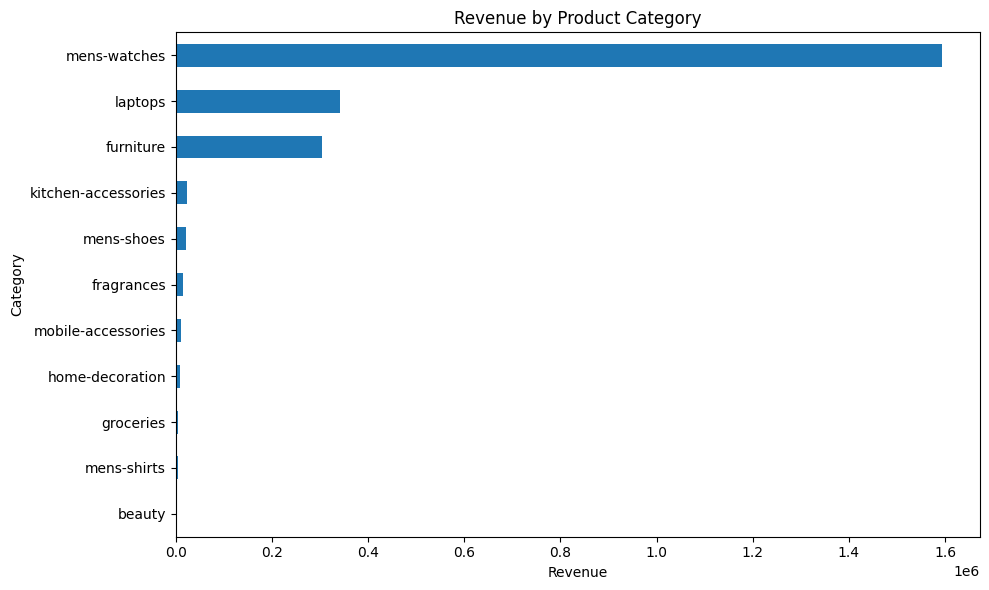

In [11]:
# Revenue by category

plt.figure(figsize=(10, 6))

category_analysis["revenue"].sort_values().plot(
    kind="barh"
)

plt.title("Revenue by Product Category")
plt.xlabel("Revenue")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

### Revenue by Category — Interpretation

The category-level revenue analysis shows substantial differences in revenue contribution across product categories.

- **mens-watches** generated the highest revenue in the synthetic dataset at **1,593,009.92**, despite having only **85 orders**.
- **laptops** generated **340,960.26** from **77 orders**, while **furniture** generated **304,119.57** from **95 orders**.
- **kitchen-accessories** had the highest number of orders at **423** and the highest quantity sold at **1,256**, but its revenue was **22,662.04**.
- **groceries** also had high order volume with **407 orders** and **1,213 units**, but generated only **5,858.16** in revenue.
- The difference between order volume and revenue indicates that product price has a major effect on category-level revenue.

These observations are based entirely on the synthetic customer-order dataset generated for this project and should not be interpreted as real Zepto business performance.

In [15]:
# Monthly revenue analysis

monthly_revenue = (
    df.groupby(df["order_date"].dt.to_period("M"))["order_amount"]
      .sum()
      .reset_index()
)

monthly_revenue["order_date"] = monthly_revenue["order_date"].astype(str)

display(monthly_revenue)

,order_date,order_amount
0,2026-01,428445.94
1,2026-02,413192.09
2,2026-03,524463.32
3,2026-04,290058.52
4,2026-05,269506.61
5,2026-06,406032.94


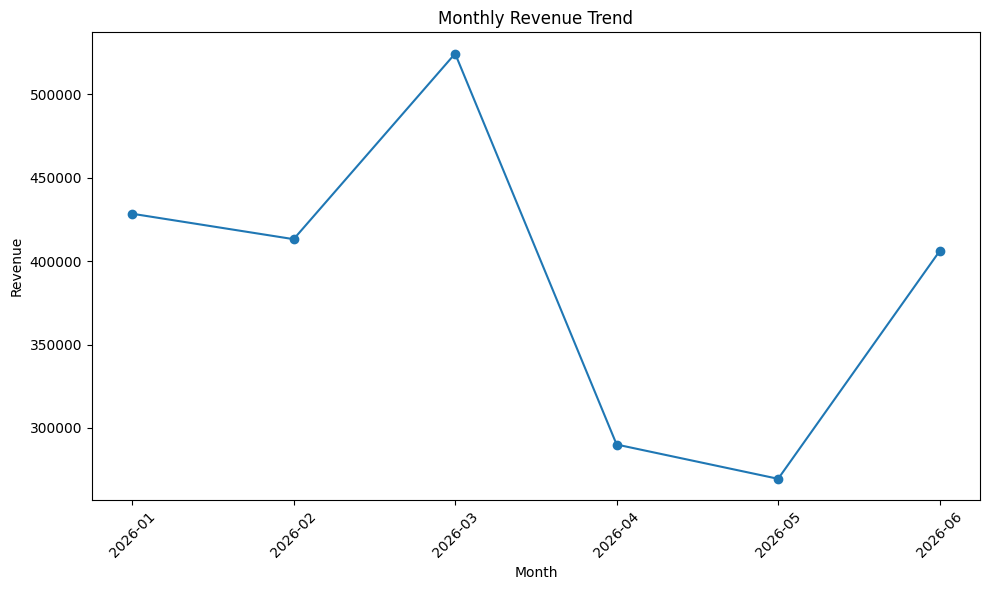

In [17]:
# Monthly revenue trend

plt.figure(figsize=(10, 6))

plt.plot(
    monthly_revenue["order_date"],
    monthly_revenue["order_amount"],
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Monthly Revenue Trend — Interpretation

The monthly revenue trend shows noticeable variation across the six-month synthetic dataset.

- Revenue increased from **428,445.94 in January** to **524,463.32 in March**, which was the highest monthly revenue.
- Revenue then declined substantially in April to **290,058.52** and reached the lowest level of **269,506.61 in May**.
- Revenue recovered to **406,032.94 in June**.
- Overall, the trend does not show a steady increase or decrease; instead, revenue fluctuates considerably across months.

These patterns describe the synthetic dataset generated for this project and should not be interpreted as actual Zepto sales trends.

In [20]:
# Load customer-level engineered features

customer_features = pd.read_csv("../data/features/customer_features.csv")

print("Customer feature dataset shape:", customer_features.shape)

display(customer_features.head())

Customer feature dataset shape: (298, 11)


,customer_id,total_orders,total_spend,average_order_value,total_quantity,average_discount,average_rating,unique_categories,unique_products,days_since_last_order,customer_lifetime_days
0,CUST_0001,3,3837.63,1279.210000,8,9.873333,4.180000,2,3,70,16
1,CUST_0002,11,17797.43,1617.948182,35,9.053636,3.342727,7,11,8,164
2,CUST_0003,3,4925.77,1641.923333,5,12.923333,4.323333,3,3,5,163
3,CUST_0004,2,327.73,163.865000,6,13.105000,3.895000,2,2,14,73
4,CUST_0005,2,144.12,72.060000,3,4.655000,3.675000,2,2,52,84


In [22]:
# Customer spending summary

print("Total customer spend:", round(customer_features["total_spend"].sum(), 2))
print("Average customer spend:", round(customer_features["total_spend"].mean(), 2))
print("Median customer spend:", round(customer_features["total_spend"].median(), 2))

print("\nTop 10 customers by total spend:")

top_customers = (
    customer_features[
        ["customer_id", "total_orders", "total_spend", "average_order_value"]
    ]
    .sort_values("total_spend", ascending=False)
    .head(10)
)

display(top_customers)

Total customer spend: 2331699.42
Average customer spend: 7824.49
Median customer spend: 1313.25

Top 10 customers by total spend:


,customer_id,total_orders,total_spend,average_order_value
124,CUST_0125,10,67855.25,6785.525000
86,CUST_0087,7,67704.74,9672.105714
63,CUST_0064,5,67200.38,13440.076000
10,CUST_0011,3,61847.90,20615.966667
45,CUST_0046,7,59794.50,8542.071429
254,CUST_0257,6,55678.68,9279.780000
6,CUST_0007,5,46855.99,9371.198000
182,CUST_0184,6,45369.88,7561.646667
216,CUST_0218,4,43479.44,10869.860000
143,CUST_0144,6,43371.20,7228.533333


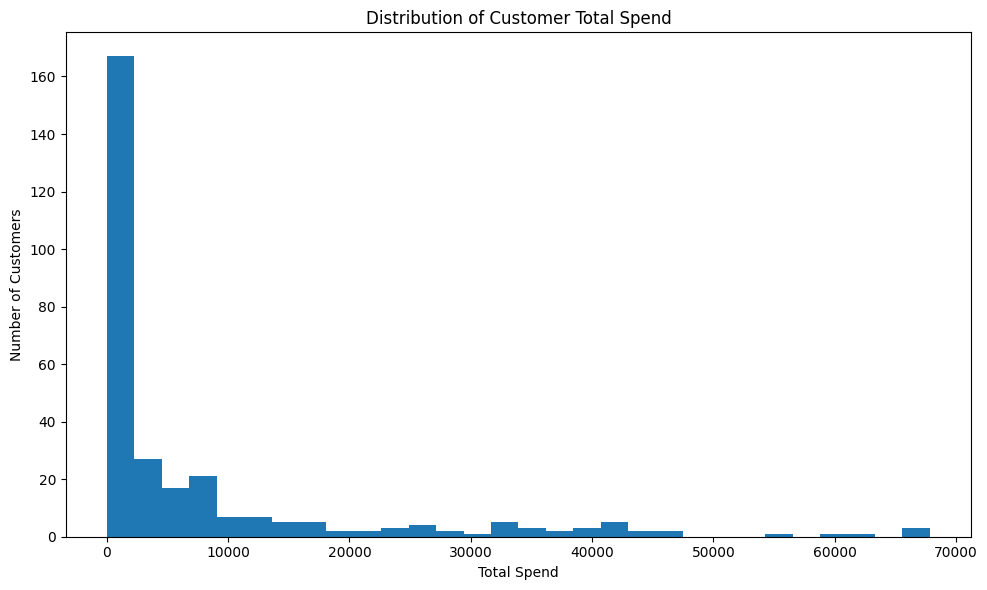

In [24]:
# Distribution of customer spending

plt.figure(figsize=(10, 6))

plt.hist(
    customer_features["total_spend"],
    bins=30
)

plt.title("Distribution of Customer Total Spend")
plt.xlabel("Total Spend")
plt.ylabel("Number of Customers")
plt.tight_layout()
plt.show()

### Customer Spending Distribution — Interpretation

The customer spending distribution is strongly right-skewed.

- Most customers have relatively lower total spending.
- A smaller group of customers has substantially higher total spending.
- The long right tail indicates the presence of high-value customers in the synthetic dataset.
- This variation in customer spending is useful for customer segmentation and machine-learning analysis.
- Because the distribution is skewed, the mean may be influenced by a relatively small number of high-spending customers.

These observations are based on the synthetic customer-order dataset created for this project.

In [27]:
# Load the prepared machine-learning dataset

ml_data = pd.read_csv("../data/ml/customer_ml_data.csv")

print("ML dataset shape:", ml_data.shape)

print("\nTarget distribution:")
display(ml_data["inactive_customer"].value_counts())

print("\nTarget distribution (%):")
display(
    (ml_data["inactive_customer"].value_counts(normalize=True) * 100)
    .round(2)
)

ML dataset shape: (298, 12)

Target distribution:


inactive_customer
0    239
1     59
Name: count, dtype: int64


Target distribution (%):


inactive_customer
0    80.2
1    19.8
Name: proportion, dtype: float64

## Machine Learning — Customer Inactivity Prediction

### Target Definition

The machine-learning task is to classify customers as active or inactive.

The target variable is `inactive_customer`:

- `0` = Active customer
- `1` = Inactive customer

A customer is classified as inactive when:

`days_since_last_order > 60`

Otherwise, the customer is classified as active.

The 60-day threshold is a project assumption created for this synthetic dataset. It is not a real Zepto business rule.

The resulting dataset contains:

- **80.2% active customers**
- **19.8% inactive customers**

Because the target classes are imbalanced, model evaluation considers precision, recall, F1-score, ROC-AUC, and accuracy rather than relying only on accuracy.

In [30]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report
)

# Features used for prediction
feature_columns = [
    "total_orders",
    "total_spend",
    "average_order_value",
    "total_quantity",
    "average_discount",
    "average_rating",
    "unique_categories",
    "unique_products",
    "customer_lifetime_days"
]

X = ml_data[feature_columns]
y = ml_data["inactive_customer"]

print("Number of features:", X.shape[1])
print("Features used:")
print(feature_columns)

Number of features: 9
Features used:
['total_orders', 'total_spend', 'average_order_value', 'total_quantity', 'average_discount', 'average_rating', 'unique_categories', 'unique_products', 'customer_lifetime_days']


In [32]:
# Train-test split with stratification

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test.value_counts(normalize=True).round(3))

Training samples: 238
Testing samples: 60

Training target distribution:
inactive_customer
0    0.803
1    0.197
Name: proportion, dtype: float64

Testing target distribution:
inactive_customer
0    0.8
1    0.2
Name: proportion, dtype: float64


In [34]:
# Standardize numerical features for Logistic Regression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training feature matrix:", X_train_scaled.shape)
print("Testing feature matrix:", X_test_scaled.shape)

Training feature matrix: (238, 9)
Testing feature matrix: (60, 9)


In [36]:
# Train Logistic Regression

logistic_model = LogisticRegression(
    random_state=42,
    max_iter=1000,
    class_weight="balanced"
)

logistic_model.fit(X_train_scaled, y_train)

logistic_predictions = logistic_model.predict(X_test_scaled)
logistic_probabilities = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("Logistic Regression training completed.")

Logistic Regression training completed.


In [38]:
# Evaluate Logistic Regression

logistic_accuracy = accuracy_score(y_test, logistic_predictions)
logistic_precision = precision_score(y_test, logistic_predictions)
logistic_recall = recall_score(y_test, logistic_predictions)
logistic_f1 = f1_score(y_test, logistic_predictions)
logistic_roc_auc = roc_auc_score(y_test, logistic_probabilities)

print("Logistic Regression Performance")
print("--------------------------------")
print("Accuracy :", round(logistic_accuracy, 6))
print("Precision:", round(logistic_precision, 6))
print("Recall   :", round(logistic_recall, 6))
print("F1 Score :", round(logistic_f1, 6))
print("ROC-AUC  :", round(logistic_roc_auc, 6))

print("\nClassification Report:")
print(classification_report(y_test, logistic_predictions))

Logistic Regression Performance
--------------------------------
Accuracy : 0.883333
Precision: 0.727273
Recall   : 0.666667
F1 Score : 0.695652
ROC-AUC  : 0.944444

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.94      0.93        48
           1       0.73      0.67      0.70        12

    accuracy                           0.88        60
   macro avg       0.82      0.80      0.81        60
weighted avg       0.88      0.88      0.88        60



### Logistic Regression — Interpretation

The Logistic Regression model achieved an accuracy of **88.33%** and a ROC-AUC of **0.9444** on the test set.

For the inactive-customer class:

- Precision was **72.73%**, meaning that most customers predicted as inactive were actually inactive.
- Recall was **66.67%**, meaning the model identified two-thirds of the actual inactive customers.
- The F1-score was **69.57%**, providing a balance between precision and recall.

The ROC-AUC of **0.9444** indicates strong separation between the active and inactive classes in this test set.

Because the dataset is synthetic and relatively small, these results should be interpreted as a demonstration of the machine-learning workflow rather than as a production performance estimate.

In [41]:
# Train Random Forest

random_forest_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    random_state=42,
    class_weight="balanced"
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)
rf_probabilities = random_forest_model.predict_proba(X_test)[:, 1]

print("Random Forest training completed.")

Random Forest training completed.


In [43]:
# Evaluate Random Forest

rf_accuracy = accuracy_score(y_test, rf_predictions)
rf_precision = precision_score(y_test, rf_predictions)
rf_recall = recall_score(y_test, rf_predictions)
rf_f1 = f1_score(y_test, rf_predictions)
rf_roc_auc = roc_auc_score(y_test, rf_probabilities)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 6))
print("Precision:", round(rf_precision, 6))
print("Recall   :", round(rf_recall, 6))
print("F1 Score :", round(rf_f1, 6))
print("ROC-AUC  :", round(rf_roc_auc, 6))

print("\nClassification Report:")
print(classification_report(y_test, rf_predictions))

Random Forest Performance
-------------------------
Accuracy : 0.883333
Precision: 0.777778
Recall   : 0.583333
F1 Score : 0.666667
ROC-AUC  : 0.965278

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.96      0.93        48
           1       0.78      0.58      0.67        12

    accuracy                           0.88        60
   macro avg       0.84      0.77      0.80        60
weighted avg       0.88      0.88      0.88        60



In [45]:
# Model comparison

model_comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [logistic_accuracy, rf_accuracy],
    "Precision": [logistic_precision, rf_precision],
    "Recall": [logistic_recall, rf_recall],
    "F1 Score": [logistic_f1, rf_f1],
    "ROC-AUC": [logistic_roc_auc, rf_roc_auc]
})

display(model_comparison.round(4))

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8833,0.7273,0.6667,0.6957,0.9444
1,Random Forest,0.8833,0.7778,0.5833,0.6667,0.9653


### Model Comparison — Interpretation

Both models achieved an accuracy of **88.33%** on the test set.

The models show different performance characteristics:

- Logistic Regression achieved **72.73% precision**, **66.67% recall**, **69.57% F1-score**, and **94.44% ROC-AUC**.
- Random Forest achieved **77.78% precision**, **58.33% recall**, **66.67% F1-score**, and **96.53% ROC-AUC**.
- Random Forest produced a higher ROC-AUC and precision, while Logistic Regression produced higher recall and F1-score.
- The results demonstrate that model evaluation should consider multiple metrics rather than relying only on accuracy.

The evaluation is based on a test set of 60 customers from the synthetic dataset. Therefore, the results should be interpreted as a project demonstration rather than a production performance estimate.

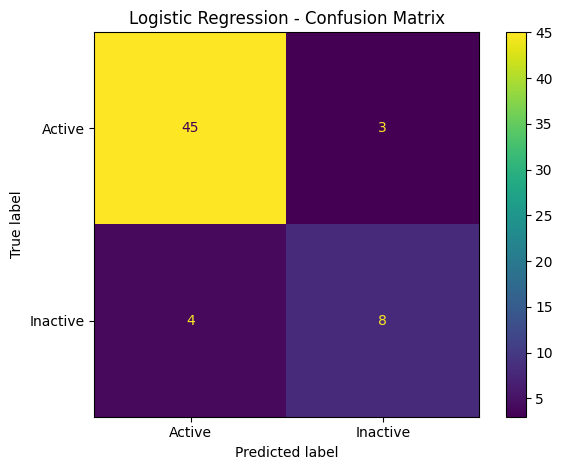

In [48]:
from sklearn.metrics import ConfusionMatrixDisplay

# Logistic Regression confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test,
    logistic_predictions,
    display_labels=["Active", "Inactive"]
)

plt.title("Logistic Regression - Confusion Matrix")
plt.tight_layout()
plt.show()

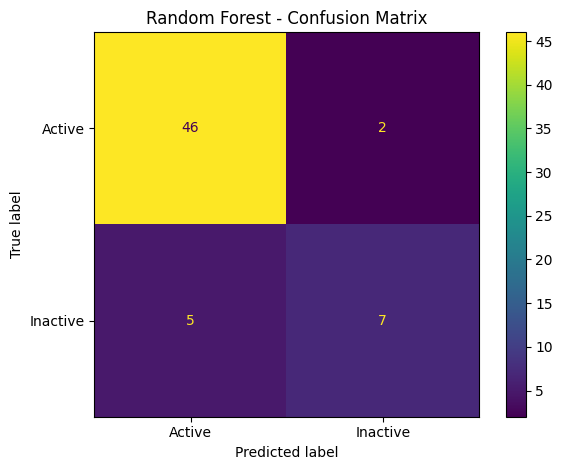

In [50]:
# Random Forest confusion matrix

ConfusionMatrixDisplay.from_predictions(
    y_test,
    rf_predictions,
    display_labels=["Active", "Inactive"]
)

plt.title("Random Forest - Confusion Matrix")
plt.tight_layout()
plt.show()

### Confusion Matrix — Interpretation

The confusion matrices provide a detailed view of the classification results on the 60-customer test set.

#### Logistic Regression

- 45 active customers were correctly classified as active.
- 3 active customers were classified as inactive.
- 4 inactive customers were classified as active.
- 8 inactive customers were correctly classified as inactive.

#### Random Forest

- 46 active customers were correctly classified as active.
- 2 active customers were classified as inactive.
- 5 inactive customers were classified as active.
- 7 inactive customers were correctly classified as inactive.

The confusion matrices show the trade-off between correctly identifying inactive customers and avoiding incorrect inactive predictions.

In [53]:
# Random Forest feature importance

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": random_forest_model.feature_importances_
})

feature_importance = (
    feature_importance
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

display(feature_importance)

,feature,importance
0,customer_lifetime_days,0.400145
1,total_quantity,0.115245
2,total_spend,0.104560
3,total_orders,0.077857
4,average_order_value,0.073048
5,average_discount,0.069730
6,average_rating,0.069281
7,unique_products,0.055470
8,unique_categories,0.034663


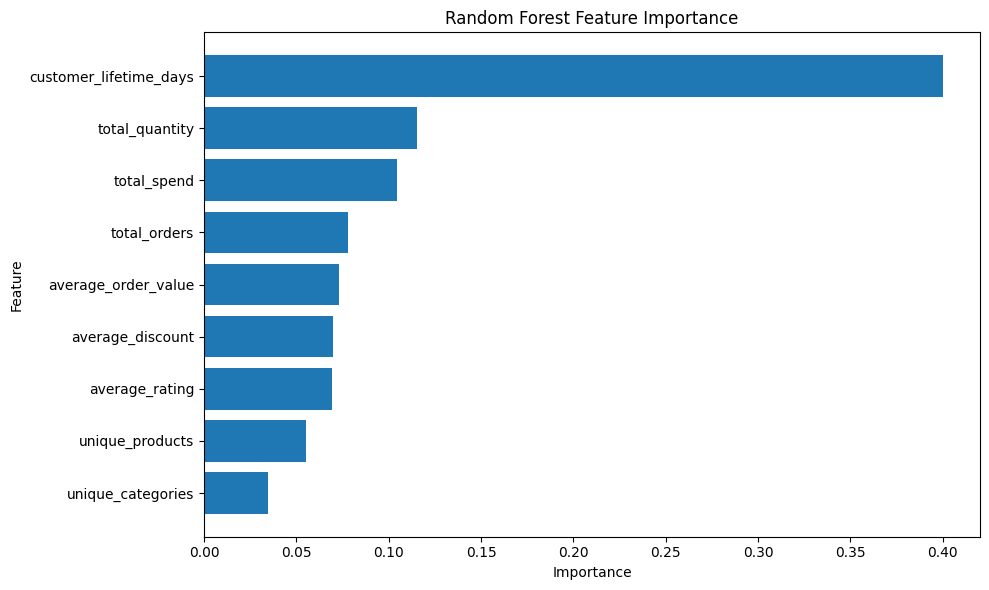

In [55]:
# Plot Random Forest feature importance

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

### Feature Importance — Interpretation

The Random Forest feature-importance analysis shows how strongly each feature contributed to the model's predictions.

- `customer_lifetime_days` had the highest model importance at approximately **0.4001**.
- `total_quantity` was the next most important feature at approximately **0.1152**.
- `total_spend` had an importance of approximately **0.1046**.
- `total_orders` and `average_order_value` had importance values of approximately **0.0779** and **0.0730**, respectively.
- `average_discount`, `average_rating`, `unique_products`, and `unique_categories` had comparatively smaller importance values.

Feature importance represents the Random Forest model's reliance on these variables for making predictions. It should not be interpreted as evidence that a feature directly causes customer inactivity.

The relatively high importance of `customer_lifetime_days` should also be interpreted carefully because the dataset is synthetically generated and the target is based on a recency threshold.

In [58]:
# Final model results summary

final_results = model_comparison.round(4)

print("Final Model Evaluation Results")
print("==============================")
display(final_results)

print("\nMost important Random Forest features:")
display(feature_importance.round(4))

Final Model Evaluation Results


,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.8833,0.7273,0.6667,0.6957,0.9444
1,Random Forest,0.8833,0.7778,0.5833,0.6667,0.9653



Most important Random Forest features:


,feature,importance
0,customer_lifetime_days,0.4001
1,total_quantity,0.1152
2,total_spend,0.1046
3,total_orders,0.0779
4,average_order_value,0.0730
5,average_discount,0.0697
6,average_rating,0.0693
7,unique_products,0.0555
8,unique_categories,0.0347


## Conclusion

This notebook demonstrated an end-to-end customer analytics and machine-learning workflow using a synthetic customer-order dataset.

The analysis covered:

1. Exploratory analysis of order, revenue, category, and monthly trends.
2. Customer-level feature engineering using purchasing behavior.
3. Definition of a synthetic customer inactivity target using a 60-day recency threshold.
4. Prevention of target leakage by excluding `days_since_last_order` from the model features.
5. Training and evaluation of Logistic Regression and Random Forest classifiers.
6. Evaluation using accuracy, precision, recall, F1-score, ROC-AUC, and confusion matrices.
7. Analysis of Random Forest feature importance.

Both models achieved **88.33% accuracy** on the 60-customer test set, while showing different precision, recall, F1-score, and ROC-AUC characteristics.

The feature-importance analysis showed that `customer_lifetime_days` had the highest contribution to the Random Forest predictions. This should be interpreted as model feature importance rather than causal influence.

### Limitations

- The customer and order data is synthetically generated.
- The dataset contains only 298 customers and 1,500 orders.
- The inactivity threshold of 60 days is a project assumption.
- Model performance is based on a relatively small test set of 60 customers.
- The results should not be interpreted as actual Zepto customer behavior or production model performance.

Future work could use real transaction data, additional behavioral features, hyperparameter tuning, cross-validation, and more advanced customer segmentation and prediction techniques.

In [60]:
%pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip
